# Setup

## 1.1 Install Dependencies

In [195]:
"""
Install:
- TensorFlow (tool to construct neural networks)
- OpenCV (library for reading and processing graphics)
- Matplotlib (library for plotting)
"""

!pip install tensorflow opencv-python matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1.2 Import Dependencies

In [196]:
# Import standard dependencies 

# Import OpenCV into our library
import cv2 
# Operating system makes directory/file path navigation easier
import os 
# For generating/testing new data
import random 
# Array transformation library
import numpy as np 
# Data visualizations 
from matplotlib import pyplot as plt 

# Import model components and various deep learning layers we'll need

""" 
Notes:
- TensorFlow Functional API is a lot more flexible when building DL models
- SNN allows us to do one-shot classification: pass in two images 
and determine whether those images are the same
  - Pass in two images at the same time into SNN and distance layer will 
  measure similarity between two images
  - Train NN to determine what similarity is like
    - Similar --> 1
    - Different --> 0
"""

# Import TensorFlow dependencies

# Import Model from TensorFlow's Keras library
# Model defines the architecture of NN
# Gives us: Model(inputs=[inputimage, verificiationimage],outputs=[1,0])
from tensorflow.keras.models import Model 

"""
Import:
- Layer (class that allows to define custom NN layer) 
- Conv2D (allows us to perform convolutions)
- Dense (fully connected layer)
- MaxPooling2D (divides image into sections, 
retains max value in each area to reduce size of data passed to next layer)
- Input (define what we're passing through to our model)
- Flatten (takes info from previous layer, flattens it down into one dimension
so we can pass CNN data to dense (standard) layer)
"""
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten

# Import TensorFlow to access all the tools needed to construct SNN
import tensorflow as tf

## 1.3 Set GPU Growth

In [197]:
"""
To combat TensorFlow's greediness, meaning it tries to snatch all of your 
the computer's GPU's memory at once (which results in OOM crashes), this code
will force it grow its memory usage gradually, only taking what it actually
needs.
"""

# Unnecessary for Apple Silicon

# Accessing all the different GPUs on machine
gpus = tf.config.experimental.list_physical_devices('GPU')
# Loops through GPUs and set memory growth equal to true
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

## 1.4 Create Folder Structures

In [198]:
"""
Create:
- Anchor (real-time input image)
- Positive (positive verification image)
- Negative (negative verification image)
"""

# Setup paths
# os.path.join joins different directories together to form full file path
# Setup paths
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [199]:
# Make the directories
os.makedirs(POS_PATH, exist_ok=True)
os.makedirs(NEG_PATH, exist_ok=True)
os.makedirs(ANC_PATH, exist_ok=True)

# 2. Collect Positives and Anchors

## 2.1 Collect Positive and Anchor Classes

In [15]:
# Import uuid library to generate unique image names

import uuid

In [200]:
# Establish a connection to the webcam
cap = cv2.VideoCapture(0)

# Counter for number of images saved
anchor_count = 0
positive_count = 0

# Loop through every frame in webcam
while cap.isOpened():
    ret, frame = cap.read()
    
    # Cut down frame to 950x950px
    frame = frame[150:1100, 550:1500, :]
    
    # Take and save 300 anchor images
    if anchor_count < 300:
        imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
        anchor_count += 1
    else:
        break
    
    # Show image back to screen
    cv2.imshow('Image Collection', frame)
    
    # Wait 1mS between frames
    cv2.waitKey(1)

# Release the webcam
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

-1

In [219]:
# Establish a connection to the webcam
cap = cv2.VideoCapture(0)

# Counter for number of images saved
anchor_count = 0
positive_count = 0

# Loop through every frame in webcam
while cap.isOpened():
    ret, frame = cap.read()
    
    # Cut down frame to 950x950px
    frame = frame[150:1100, 550:1500, :]
    
    # Take and save 300 positive images
    if positive_count < 300:
        imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
        positive_count += 1
    else:
        break
    
    # Show image back to screen
    cv2.imshow('Image Collection', frame)
    
    # Wait 1mS between frames
    cv2.waitKey(1)

# Release the webcam
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

-1

## 2.x NEW - Data Augmentation

In [186]:
def data_aug(img):
    data = []
    # For every anchor and positive image, now have 10x as many images because we're adding 9 additional images for every image we had!
    for i in range(9):
        # Random brightness
        img = tf.image.stateless_random_brightness(img, max_delta=0.02, seed=(1,2))
        # Random contrast
        img = tf.image.stateless_random_contrast(img, lower=0.6, upper=1, seed=(1,3))
        # img = tf.image.stateless_random_crop(img, size=(20,20,3), seed=(1,2))
        # Random flip left right
        img = tf.image.stateless_random_flip_left_right(img, seed=(np.random.randint(100),np.random.randint(100)))
        # Random JPEG quality
        img = tf.image.stateless_random_jpeg_quality(img, min_jpeg_quality=90, max_jpeg_quality=100, seed=(np.random.randint(100),np.random.randint(100)))
        # Random saturation
        img = tf.image.stateless_random_saturation(img, lower=0.9,upper=1, seed=(np.random.randint(100),np.random.randint(100)))
            
        data.append(img)
    
    return data

In [187]:
import os
import uuid

In [189]:
print(ANC_PATH)

data/anchor


In [193]:
for file_name in os.listdir(os.path.join(ANC_PATH)):
    if not file_name.lower().endswith('.jpg'):
        continue
    img_path = os.path.join(ANC_PATH, file_name)
    img = cv2.imread(img_path)
    if img is None:
        continue
    augmented_images = data_aug(img)
    
    for image in augmented_images:
        cv2.imwrite(os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1())), image.numpy())

In [203]:
for file_name in os.listdir(os.path.join(POS_PATH)):
    if not file_name.lower().endswith('.jpg'):
        continue
    img_path = os.path.join(POS_PATH, file_name)
    img = cv2.imread(img_path)
    if img is None:
        continue
    augmented_images = data_aug(img)
    
    for image in augmented_images:
        cv2.imwrite(os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1())), image.numpy())

# 3. Load and Preprocess Images

## 3.1 Get Image Directories

In [18]:
# TensorFlow makes a list of the locations where each image is
# stored locally and does for the first 300 images in each category
anchor = tf.data.Dataset.list_files(ANC_PATH+'/*.jpg').take(300)
positive = tf.data.Dataset.list_files(POS_PATH+'/*.jpg').take(300)
negative = tf.data.Dataset.list_files(NEG_PATH+'/*.jpg').take(300)

In [19]:
# Manually step through list of anchor file paths (sanity check)
dir_test = anchor.as_numpy_iterator()
# Grabs the next item we're pointing at to verify files were found
print(dir_test.next())

b'data/anchor/a68943d8-1510-11f1-a24c-8a8a088db03b.jpg'


## 3.2 Preprocessing - Scale and Resize

In [20]:
def preprocess(file_path):
    # Read in image from file path
    byte_img = tf.io.read_file(file_path)
    # Load the image
    img = tf.io.decode_jpeg(byte_img)
    # Preprocessing steps - resizing the image to be 100x100x3
    img = tf.image.resize(img, (100, 100))
    # Scale image to be between 0 and 1
    img = img / 255.0
    # Return image
    return img

## 3.3 Create Labelled Dataset

In [21]:
# Zips together every anchor image with a positive image and puts a label of 1 on each pair
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
# Zips together every anchor image with a negative image and puts a label of 0 on each pair
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
# Combine both lists into one big dataset
data = positives.concatenate(negatives)

In [22]:
# Iterator to step through combined dataset
samples = data.as_numpy_iterator()
# Prints item we're pointing at (sanity check)
samples.next()

(b'data/anchor/31b4398e-1432-11f1-a0c6-8a8a088db03b.jpg',
 b'data/positive/960ec806-14c1-11f1-a0c6-8a8a088db03b.jpg',
 np.float32(1.0))

## 3.4 Build Train and Test Partition

In [23]:
# Need a function to process a twin (load in both images and return it back to dataset)
def preprocess_twin(input_img, validation_img, label):
    return (preprocess(input_img), preprocess(validation_img), label)

In [24]:
# Test preprocess_twin on one example
example = samples.next()
res = preprocess_twin(*example)

In [25]:
# First anchor image after its been preprocessed (10,000 pixels with RGB vals)
res[0]

<tf.Tensor: shape=(100, 100, 3), dtype=float32, numpy=
array([[[0.5254902 , 0.46666667, 0.39215687],
        [0.5254902 , 0.46666667, 0.39215687],
        [0.5128922 , 0.4697549 , 0.39132354],
        ...,
        [0.44411764, 0.4127451 , 0.3382353 ],
        [0.4465196 , 0.4122059 , 0.33867648],
        [0.44705883, 0.41568628, 0.34117648]],

       [[0.5127451 , 0.46960783, 0.39117646],
        [0.5137255 , 0.47058824, 0.39215687],
        [0.50784314, 0.4735294 , 0.39215687],
        ...,
        [0.45588234, 0.41568628, 0.34411764],
        [0.44936275, 0.41504902, 0.34151962],
        [0.45544118, 0.4123039 , 0.34171566]],

       [[0.5147059 , 0.4715686 , 0.39313725],
        [0.5176471 , 0.4745098 , 0.39607844],
        [0.51691175, 0.47377452, 0.39534312],
        ...,
        [0.45563725, 0.4125    , 0.34191176],
        [0.44705883, 0.41568628, 0.34117648],
        [0.45490196, 0.4117647 , 0.34117648]],

       ...,

       [[0.36568627, 0.3382353 , 0.2990196 ],
        [0.36

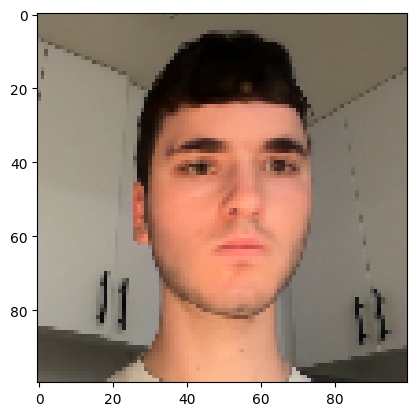

In [26]:
plt.imshow(res[0])

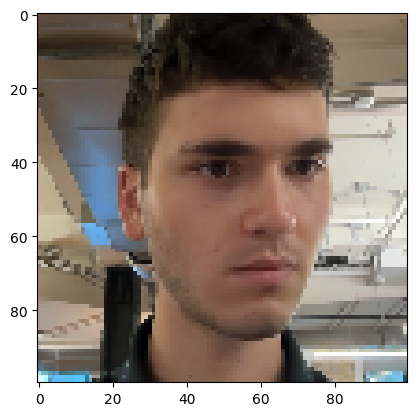

In [27]:
# Second image (positive or negative) after preprocessing
plt.imshow(res[1])

In [28]:
# Label value from first pair (1.0 = same person, 0.0 = different person)
res[2]

np.float32(1.0)

In [29]:
# Build dataloader pipeline
# Running preprocess twin function which returns preprocessed image for anchor, for validation, and label
data = data.map(preprocess_twin)
# Caching images (save preprocessed images in memory so we don't have to reprocess them every time)
data = data.cache()
# Shuffle up images so model doesn't learn order - forces it to actually learn face differences
data = data.shuffle(buffer_size=10000)

In [30]:
# Training partition
# Grabbing first 70% of our dataset as training partition
train_data = data.take(round(len(data)*.7))
# Pass in our images in groups of 16 - model processes 16 at a time
train_data = train_data.batch(16)     
# Start preprocessing next set of images while we're training on current batch - prevents bottleneck
train_data = train_data.prefetch(8)

In [31]:
# Testing partition
# Skip first 70 percent of dataset so we don't pick up training observations
test_data = data.skip(round(len(data)*.7))
# Allocated last 30 percent for test data
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

In [32]:
# Size of training data (should be 420)
round(len(data)*.7)

420

In [33]:
# Size of test data (should be 180)
round(len(data)*.3)

180

# Model Engineering

## 4.1 Build Embedding Layer

In [34]:
# Blueprint for our neural network
def make_embedding():
    # Input layer - accepts 100x100 image with 3 colour channels (RGB)
    inp = Input(shape=(100, 100, 3), name='input_image')

    # First block
    # Convolution composed of 64 filters with 10x10 shape and ReLu activation
    c1 = Conv2D(64, (10, 10), activation='relu')(inp)
    # Every MaxPooling is applied, image gets smaller because 2x2 window can't hang off edges
    # - only works where it has a full 2x2 area. Over many layers, this means that there is size
    # loss. By setting padding to same, it adds a border of zeros around the image before undergoing
    # max pooling so now the 2x2 window has enough room to cover entire image which keeps the output
    # size consistent throughout the network.
    m1 = MaxPooling2D(64, (2, 2), padding='same')(c1)

    # Second block
    # Convolution of 128 filters with 7x7 shape + ReLu activation and passing through results of MaxPooling layer
    c2 = Conv2D(128, (7, 7), activation='relu')(m1)
    # Max pooling of 64 units with 2x2 shape, padding same for consistent sizing
    m2 = MaxPooling2D(64, (2, 2), padding='same')(c2)

    # Third block
    # Convolution of 128 filters with 4x4 shape, ReLu activation, m2 as input to c3
    c3 = Conv2D(128, (4, 4), activation='relu')(m2)
    # Max Pooling of 64 units with 2x2 shape, same padding, and input c3 layer
    m3 = MaxPooling2D(64, (2, 2), padding='same')(c3)

    # Final embedding block
    # Convolution of 256 filters with 4x4 shape, ReLu activation, and m3 layer as input
    c4 = Conv2D(256, (4, 4), activation='relu')(m3)
    # Flattening convolution layer from 3D into 1D
    f1 = Flatten()(c4)
    # Compresses flattened numbers into list of 4096 numbers that depict unique "fingerprint" of face
    # Sigmoid squishes all values between 0 and 1
    # This 4096 vector is what gets compared between two images to see if they are the same person
    # Measure distance between the two vectors - small distance means same person
    d1 = Dense(4096, activation='sigmoid')(f1)

    # Return final embedding model
    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [35]:
embedding = make_embedding()

In [36]:
embedding.summary()

Model: "embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 17, 17, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

## 4.2 Build Distance Layer

In [37]:
# L1Dist inherits all the functionalities of its parent class Layer
# Siamese L1 Distance class
class L1Dist(Layer):
    # Constructor
    # Init method - inheritance
    def __init__(self, **kwargs):
        # Calls parent class's constructor
        super().__init__()

    # Simiilarity calculation
    # When two face embeddings need to get compared, this function gets called
    def call(self, input_embedding, validation_embedding):
        # Return absolute value of distance between input and validation embedding
        return tf.math.abs(input_embedding[0] - validation_embedding[0])

## 4.3 Make Siamese Model

In [38]:
# Inputs 
input_image = Input(name='input_img', shape=(100,100,3))
validation_image = Input(name='validation_img', shape=(100,100,3))

In [39]:
# Pass inputs through same embedding network
inp_embedding = embedding(input_image)
val_embedding = embedding(validation_image)

In [40]:
inp_embedding

[<KerasTensor shape=(None, 4096), dtype=float32, sparse=False, ragged=False, name=keras_tensor_9>]

In [41]:
val_embedding

[<KerasTensor shape=(None, 4096), dtype=float32, sparse=False, ragged=False, name=keras_tensor_10>]

In [42]:
# Create layer object
siamese_layer = L1Dist()

In [43]:
# Siamese layer
siamese_layer(inp_embedding, val_embedding)

<KerasTensor shape=(None, 4096), dtype=float32, sparse=False, ragged=False, name=keras_tensor_11>

In [44]:
# Computes element-wise absolute difference between the two 4096-element vectors and stores it in 4096-element vector
distances = siamese_layer(inp_embedding, val_embedding)

In [45]:
distances

<KerasTensor shape=(None, 4096), dtype=float32, sparse=False, ragged=False, name=keras_tensor_12>

In [46]:
# Takes the 4096 vlaues and compresses them to 1 number
classifier = Dense(1, activation='sigmoid')(distances)

In [47]:
classifier

<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_13>

In [48]:
# Create full Keras model - entire graph from inputs to classifier defined
siamese_network = Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [49]:
siamese_network.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist (L1Dist)    │ (None, 4096)      │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      4,097 │ l1_dist[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
def make_siamese_model():

    # Anchor image in the network
    input_image = Input(name='input_img', shape=(100,100,3))

    # Validation image in the network
    validation_image = Input(name='validation_img', shape=(100,100,3))

    # Combine siamese distance components
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))

    # Classification layer
    # Passing 4096 values in which depict difference between the 4096 values of the input embedding
    # and the 4096 avlues of the validation embedding respectively
    classifier = Dense(1, activation='sigmoid')(distances)

    # Return base Model class with inputs as image and validation image and output as classifier
    # Both streams running simultaneously, combine together on L1 distance layer, and output classification layer
    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [51]:
siamese_model = make_siamese_model()

In [52]:
siamese_model.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist_1 (L1Dist)  │ (None, 4096)      │          0 │ embedding[2][0],  │
│                     │                   │            │ embedding[3][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │      4,097 │ l1_dist_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

# 5. Training

## 5.1 Setup Loss and Optimizer

In [53]:
# SNN flow:
# Use model
# Pass through data
# Get prediction
# Calculate loss using binary cross-entropy
# Calculate gradients for all weights across network
# Use optimizer to backpropagate through network to minimize loss

# Standard flow for NN:
# Make a prediction
# Calculate loss
# Derive gradients
# Calculate new weights and apply

In [54]:
# Purpose of network is to minimize loss

# Optimizer to perform backpropagation

# Could pass in logits=True as an argument if inputs to function are not normalized

# Loss function
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [55]:
# Adam optimizer
opt = tf.keras.optimizers.Adam(1e-4)

## 5.2 Establish Checkpoints

In [56]:
# If something goes wrong as we are training, we have placeholder we can go back to to reload neural network from

# Define directory to save all checkpoints
checkpoint_dir = './training_checkpoints'
# Prefix all our checkpoints such that they start with ckpt
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
# Setting up checkpoint that tracks weights and Siamese model so their weights and training state can be saved and restored later.
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

## 5.3 Build Train Step Function

In [57]:
# Converted training dataset into something iterable
test_batch = train_data.as_numpy_iterator()

In [58]:
# Pull one batch of data
batch_1 = test_batch.next()

In [59]:
# First set of images
batch_1[0]

array([[[[0.52156866, 0.4745098 , 0.38039216],
         [0.52156866, 0.4745098 , 0.38039216],
         [0.5205882 , 0.48137254, 0.38333333],
         ...,
         [0.4509804 , 0.41960785, 0.3372549 ],
         [0.45740196, 0.4260294 , 0.35151958],
         [0.45490196, 0.42352942, 0.34901962]],

        [[0.52156866, 0.48235294, 0.38431373],
         [0.52156866, 0.48235294, 0.38431373],
         [0.5107843 , 0.47941175, 0.38921568],
         ...,
         [0.44750002, 0.4239706 , 0.3376961 ],
         [0.45446077, 0.42308822, 0.34857842],
         [0.45490196, 0.42352942, 0.34901962]],

        [[0.5254902 , 0.47843137, 0.39215687],
         [0.5127451 , 0.48137254, 0.39117646],
         [0.5127451 , 0.47843137, 0.38921568],
         ...,
         [0.45392156, 0.42647058, 0.35196078],
         [0.45490196, 0.42352942, 0.34901962],
         [0.45490196, 0.42352942, 0.34901962]],

        ...,

        [[0.35465688, 0.3389706 , 0.29583332],
         [0.35      , 0.33431372, 0.29117647]

In [60]:
# Second set of images
batch_1[1]

array([[[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         ...,
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

        [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         ...,
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

        [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         ...,
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
  

In [61]:
# Labels
batch_1[2]

array([0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0.],
      dtype=float32)

In [62]:
# Contains the two image tensors
X = batch_1[:2]

In [63]:
# 2 sets, 16 examples per batch, 100x100 RGB images
np.array(X).shape

(2, 16, 100, 100, 3)

In [64]:
# Contains the labels
y = batch_1[2]

In [65]:
y

array([0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0.],
      dtype=float32)

In [66]:
# Learn more about tf.losses.BinaryCrossentropy
tf.losses.BinaryCrossentropy??

Init signature:
tf.losses.BinaryCrossentropy(
    from_logits=False,
    label_smoothing=0.0,
    axis=-1,
    reduction='sum_over_batch_size',
    name='binary_crossentropy',
    dtype=None,
)
Source:        
@keras_export("keras.losses.BinaryCrossentropy")
class BinaryCrossentropy(LossFunctionWrapper):
    """Computes the cross-entropy loss between true labels and predicted labels.

    Use this cross-entropy loss for binary (0 or 1) classification applications.
    The loss function requires the following inputs:

    - `y_true` (true label): This is either 0 or 1.
    - `y_pred` (predicted value): This is the model's prediction, i.e, a single
        floating-point value which either represents a
        [logit](https://en.wikipedia.org/wiki/Logit), (i.e, value in [-inf, inf]
        when `from_logits=True`) or a probability (i.e, value in [0., 1.] when
        `from_logits=False`).

    Args:
        from_logits: Whether to interpret `y_pred` as a tensor of
            [logit](htt

In [67]:
# Defines what happens when we train on a specific batch of data

# Wrapping function inside @tf decorator because it compiles a function into a callable TensorFlow graph
# Compiles entire neural network into a graph and allows us to go and train it efficiently
# Analogy: memorize the recipe so you don't have to reread it everytime
@tf.function

# Run one step of training using batch of data
def train_step(batch):

    # Record all math operations so we can compute gradients
    with tf.GradientTape() as tape:
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]

        # Forward pass (passing through our input features X, 
        # training equals true because certain layers will only active if training true)
        yhat = siamese_model(X, training=True)
        # Calculate loss - passing in true y value and predicted y value
        loss = binary_cross_loss(y, yhat)

    # Calculate all the gradients for our different weights with respect to our loss
    # Compute how each trainable variable (weight) should change to reduce the loss
    # Telling the optimizer how to adjust the weights of our network
    grad = tape.gradient(loss, siamese_model.trainable_variables)

    # Optimizer applying learning rate and slightly reducing loss by changing our 
    # weights to get closer to global loss minimum
    # Take the directions we just calculated for how each weight should change 
    # and update/propagate weights
    # using Adam's optimisation algorithm, a variant of gradient descent
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))

    # Return loss 
    return loss

## 5.4 Build Training Loop

In [206]:
# Import metric calculation
from tensorflow.keras.metrics import Precision, Recall

In [210]:
def train(data, EPOCHS):
    # Lists to store metrics across epochs for plotting
    precision_history = []
    recall_history = []
    
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Reset metrics at the start of each epoch
        r = Recall()
        p = Precision()
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            loss = train_step(batch)
            # Make predictions on current batch
            yhat = siamese_model.predict(batch[:2])
            # Update precision and recall with current batch results
            r.update_state(batch[2], yhat)
            p.update_state(batch[2], yhat)
            progbar.update(idx+1)
        
        # Print and store epoch metrics
        print(loss.numpy(), r.result().numpy(), p.result().numpy())
        precision_history.append(p.result().numpy())
        recall_history.append(r.result().numpy())
        
        # Save checkpoints every 10 epochs
        if epoch % 10 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)
    
    # Plot precision and recall across epochs
    plt.plot(precision_history, label='Precision')
    plt.plot(recall_history, label='Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.title('Precision and Recall over Training')
    plt.show()

## 5.5 Train the Model

In [211]:
EPOCHS = 20


 Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━

2026-03-01 20:01:11.013637: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

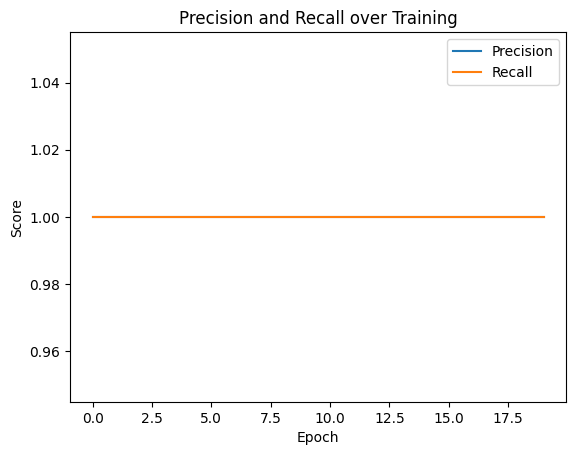

In [212]:
train(train_data, EPOCHS)

# 6. Evaluate Model

## 6.1 Import Metrics

In [213]:
"""
Notes:

HIGHER VALUES ARE BETTER

Precision - what proportion of positive identifications were actually correct 
Recall - what proportion of actual positives were identified correctly
"""

'\nNotes:\n\nHIGHER VALUES ARE BETTER\n\nPrecision - what proportion of positive identifications were actually correct \nRecall - what proportion of actual positives were identified correctly\n'

In [214]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

## 6.2 Make Predictions

In [215]:
# Take one batch of test data and store the anchor images, comparison images, and labels into three separate variables
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [216]:
# Provide next batch of test data as NumPy arrays
test_var = test_data.as_numpy_iterator().next()

In [217]:
# 16 test inputs
len(test_var[0])

16

In [106]:
# 16 validation inputs
len(test_var[1])

16

In [107]:
# 16 labels
len(test_var[2])

16

In [108]:
# Make predictions
y_hat = siamese_model.predict([test_input, test_val])
y_hat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


array([[9.9999851e-01],
       [8.8783645e-06],
       [9.3679937e-06],
       [3.7897642e-08],
       [1.9250213e-09],
       [9.9999428e-01],
       [1.1828179e-08],
       [8.3210878e-09],
       [2.6896123e-08],
       [9.9999994e-01],
       [9.7813825e-07],
       [9.9999869e-01],
       [9.9999869e-01],
       [9.9999905e-01],
       [9.9999666e-01],
       [3.5242387e-08]], dtype=float32)

In [109]:
# Post processing the results
# If y_hat is > 0.5, return 1 else return 0
[1 if prediction > 0.5 else 0 for prediction in y_hat]

[1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0]

In [110]:
y_true

array([1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0.],
      dtype=float32)

## 6.3 Calculate Metrics

In [111]:
# Creating a metric object
m = Recall()

# Calculating the recall value
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

np.float32(1.0)

In [112]:
# Creating a precision object
m = Precision()

# Calculating the recall value
m.update_state(y_true, y_hat)

# Return Precision Result
m.result().numpy()

np.float32(1.0)

## 6.4 Visualize Results

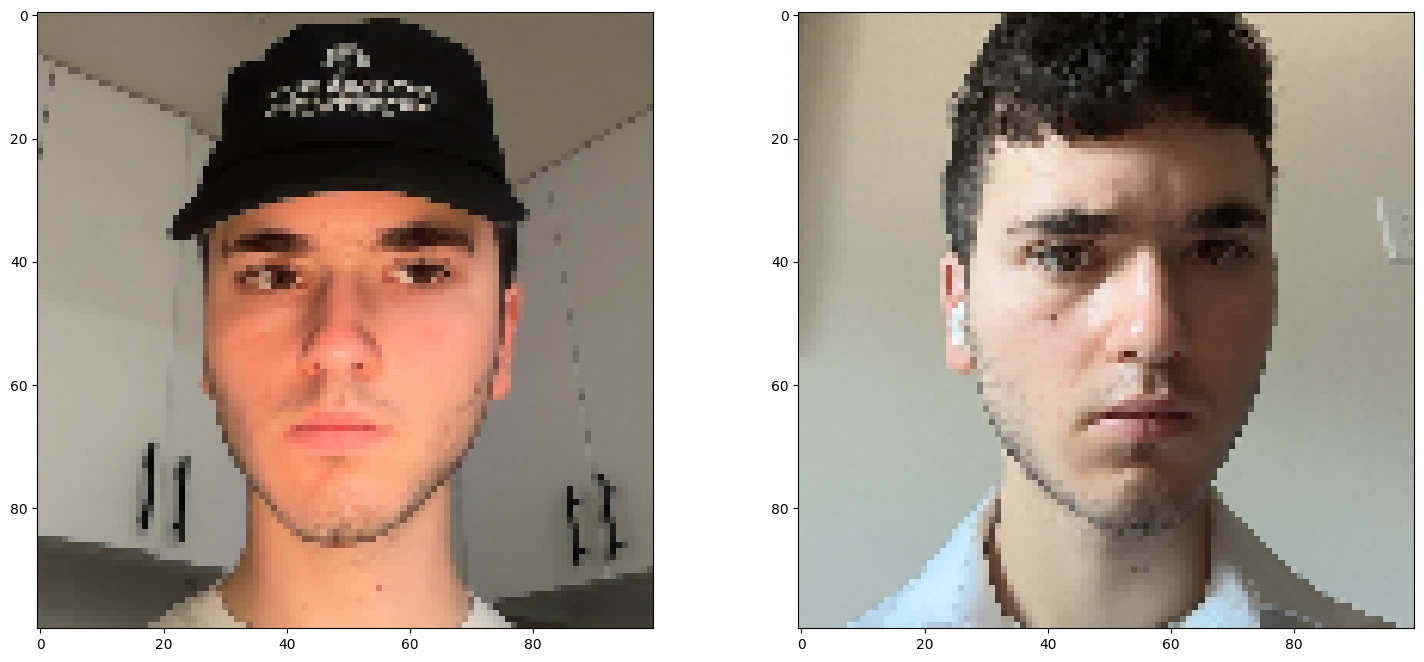

In [114]:
# PREDICTION: 1

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(test_input[0])
plt.subplot(1,2,2)
plt.imshow(test_val[0])
plt.show()

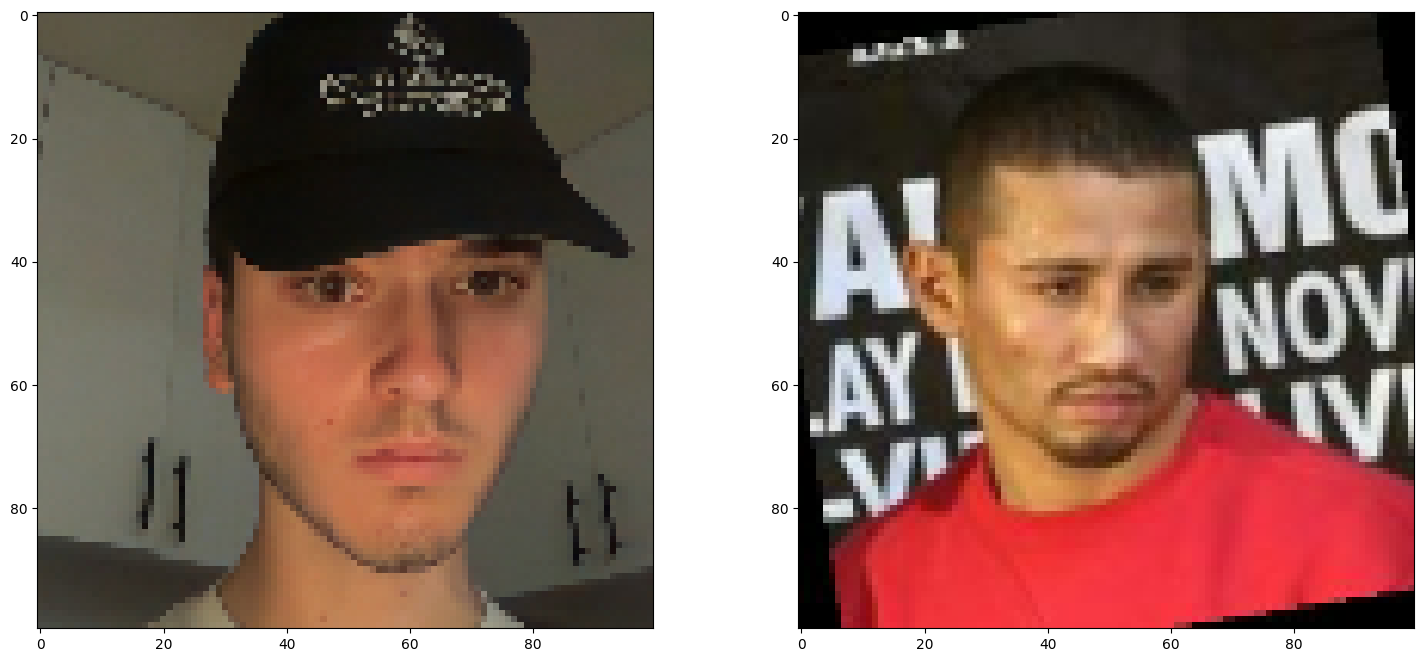

In [115]:
# PREDICTION: 0

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(test_input[1])
plt.subplot(1,2,2)
plt.imshow(test_val[1])
plt.show()

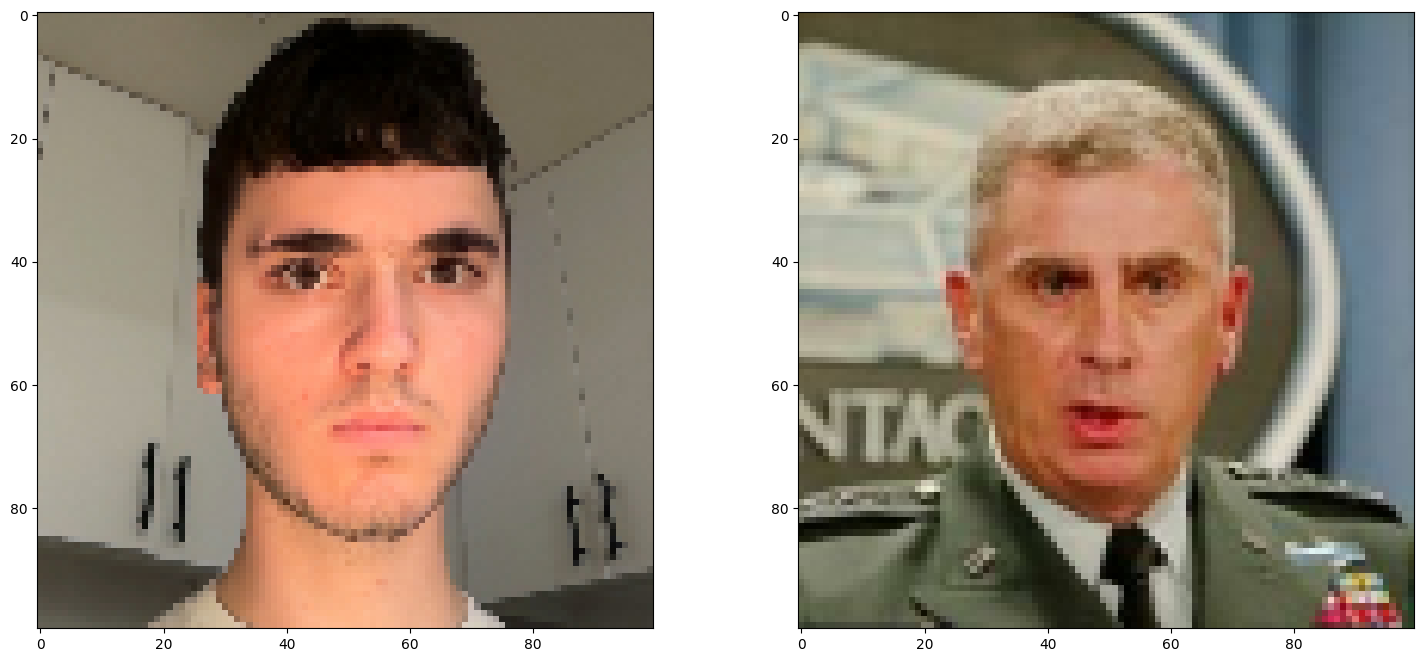

In [118]:
# PREDICTION: 0

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(test_input[2])
plt.subplot(1,2,2)
plt.imshow(test_val[2])
plt.show()

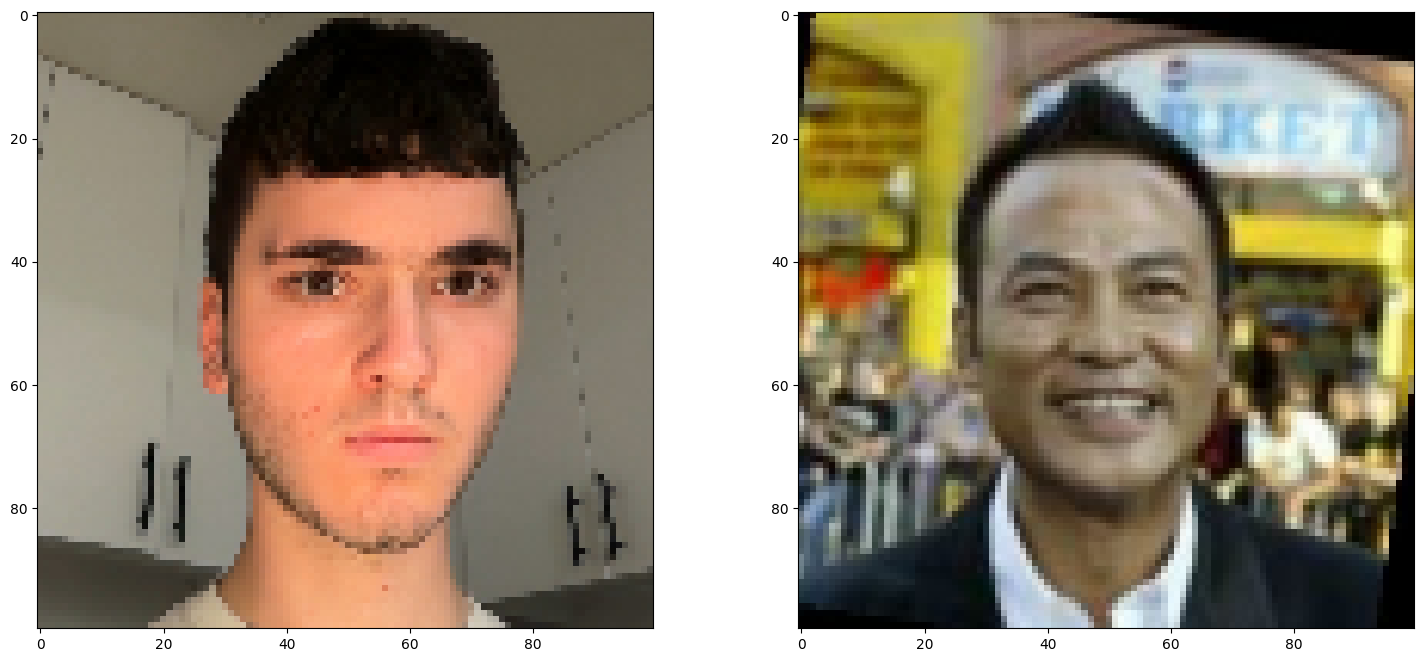

In [117]:
# PREDICTION: 0

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(test_input[3])
plt.subplot(1,2,2)
plt.imshow(test_val[3])
plt.show()

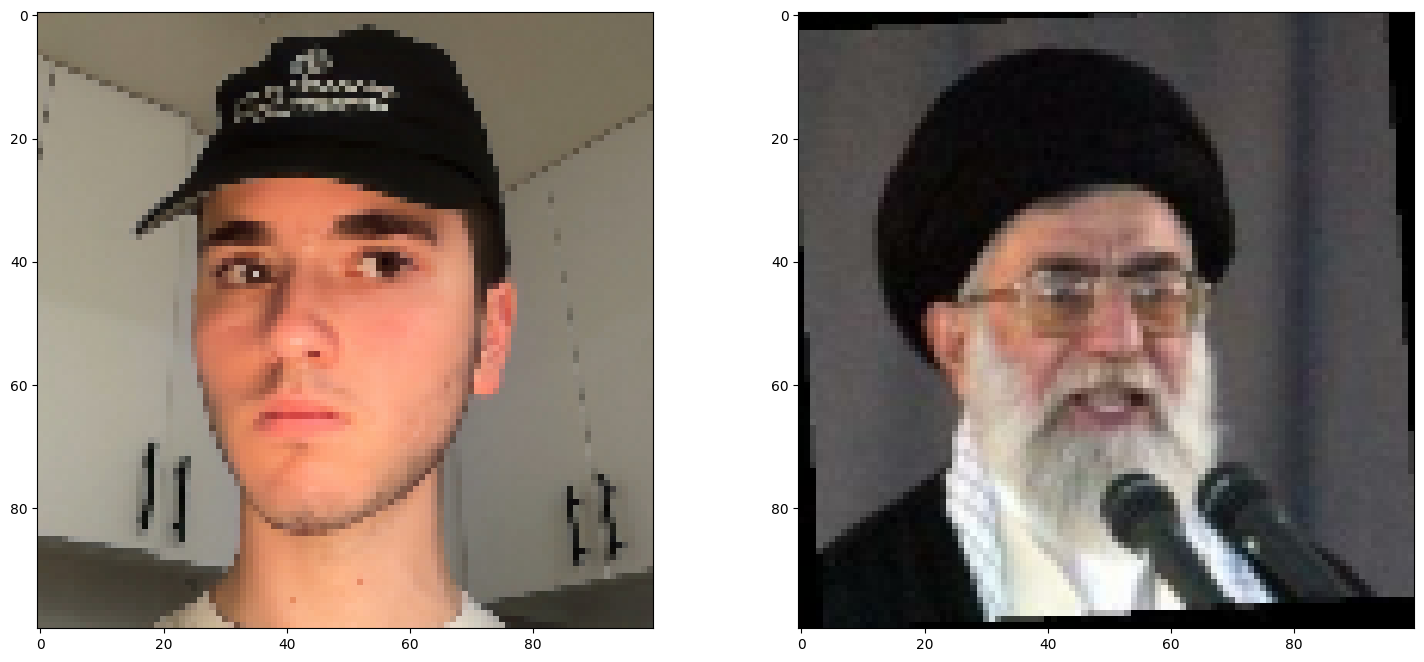

In [119]:
# PREDICTION: 0

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(test_input[4])
plt.subplot(1,2,2)
plt.imshow(test_val[4])
plt.show()

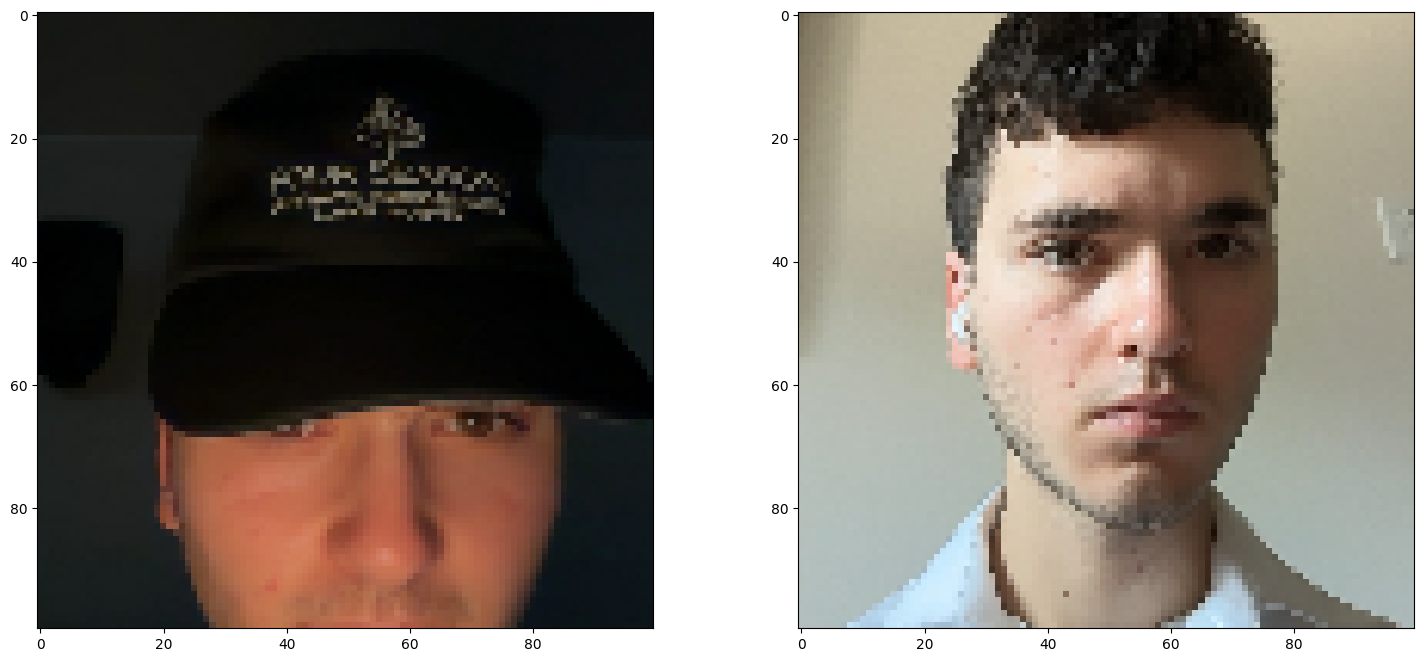

In [172]:
# PREDICTION: 1

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(test_input[5])
plt.subplot(1,2,2)
plt.imshow(test_val[5])
plt.show()

# 7. Save Model

In [218]:
# Save weights
siamese_model.save('siamesemodelv2.h5')

In [124]:
# Reload model
model = tf.keras.models.load_model('siamesemodel.h5', 
                                  custom_objects={'L1Dist':L1Dist, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy})

In [126]:
# Make predictions with reloaded model
model.predict([test_input, test_val])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


array([[9.9999851e-01],
       [8.8783645e-06],
       [9.3679937e-06],
       [3.7897642e-08],
       [1.9250213e-09],
       [9.9999428e-01],
       [1.1828179e-08],
       [8.3210878e-09],
       [2.6896123e-08],
       [9.9999994e-01],
       [9.7813825e-07],
       [9.9999869e-01],
       [9.9999869e-01],
       [9.9999905e-01],
       [9.9999666e-01],
       [3.5242387e-08]], dtype=float32)

In [127]:
# View model summary
model.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist_2 (L1Dist)  │ (None, 4096)      │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │      4,097 │ l1_dist_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

# 8. Real Time Test

## 8.1 Verification Function

In [132]:
# Shows us all the verification_images
os.listdir(os.path.join('application_data', 'verification_images'))

['b1570d30-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b2d26bbe-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b18ebe4c-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b2bda4d6-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b24da262-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b1b23c46-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b2858ed4-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b3ad36f4-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b1a2f10a-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b238232e-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b1847f86-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b1e34d86-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b2c844f4-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b1d90790-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b2764e42-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b1ed8ae4-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b3a2f70c-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b13d198e-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b2b41394-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b22e6a0a-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b305425a-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b132fc2e-1435-11f1-a0c6-8a8a088db03b.jpg',
 'b30f763a

In [130]:
# Path to locate input_image from webcam
os.path.join('application_data', 'input_image', 'input_image.jpg')

'application_data/input_image/input_image.jpg'

In [133]:
# Loop through verification images and print them out each file path
for image in os.listdir(os.path.join('application_data', 'verification_images')):
    validation_img = os.path.join('application_data', 'verification_images', image)
    print(validation_img)

application_data/verification_images/b1570d30-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b2d26bbe-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b18ebe4c-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b2bda4d6-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b24da262-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b1b23c46-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b2858ed4-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b3ad36f4-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b1a2f10a-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b238232e-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b1847f86-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b1e34d86-1435-11f1-a0c6-8a8a088db03b.jpg
application_data/verification_images/b2c844f4-1435-11f1-a0c6-8a8

In [157]:
# frame - input image
# model - trained siamese neural network
# detection_threshold - metric above which prediction is considered positive
# verification threshold - proportion of positive predictions / total positive samples
def verify(model, detection_threshold,verification_threshold):
    # Build results array
    results = [] 
    # Loop through every image in verification_images folder
    for image in os.listdir(os.path.join('application_data', 'verification_images')):

        if not image.lower().endswith('.jpg'):
            continue
        
        # Grab input image from webcam and store it in input_image folder as input_image.jpg
        input_img = preprocess(os.path.join('application_data', 'input_image', 'input_image.jpg'))
        # Grab verification (positive sample) image
        validation_img = preprocess(os.path.join('application_data', 'verification_images', image)) 

        # Stack the two images
        # Insert a dimension so each image becomes a batch of size 1
        # Convert that into list
        # Feed those batched images into Siamese model
        # Have model compare embeddings and return similarity score
        result = model.predict(list(np.expand_dims([input_img, validation_img], axis=1)))
        # Add to results array
        results.append(result)

    # Grabbing results and wrapping it in NumPy array
    # Summing up all examples that surpass detection_threshold
    # Detection threshold - determines how many positive predictions are passing detection_threshold
    detection = np.sum(np.array(results) > detection_threshold)
    # Verification threshold - proportion of positive predictions / total positive samples
    # What proportion of verification images matched input face?
    verification = detection / len(results)
    # If proportion is greater than verification threshold, person in webcam right now is verified
    verified = verification > verification_threshold

    return results, verified

## 8.2 OpenCV Real Time Verification

In [160]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    # Cut down frame to 950x950px
    frame = frame[150:1100, 550:1500, :]

    cv2.imshow('Verification', frame)

    # Verification trigger
    if cv2.waitKey(10) & 0xFF == ord('v'):
        # Save input image to application_data/input_image folder
        cv2.imwrite(os.path.join('application_data', 'input_image', 'input_image.jpg'), frame)
        # Run verification
        results, verified = verify(model, 0.5, 0.5)
        print(verified)

    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

In [161]:
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

-1

In [169]:
# Number of images that scored above 0.5 similarity
np.sum(np.squeeze(results) > 0.5)

np.int64(0)

In [162]:
results

[array([[0.09936595]], dtype=float32),
 array([[0.03180884]], dtype=float32),
 array([[0.04846612]], dtype=float32),
 array([[0.48019767]], dtype=float32),
 array([[0.2140535]], dtype=float32),
 array([[0.00738333]], dtype=float32),
 array([[0.02119042]], dtype=float32),
 array([[0.18069573]], dtype=float32),
 array([[0.03227312]], dtype=float32),
 array([[0.10031748]], dtype=float32),
 array([[0.18379259]], dtype=float32),
 array([[0.10159466]], dtype=float32),
 array([[0.02419264]], dtype=float32),
 array([[0.10914107]], dtype=float32),
 array([[0.01391463]], dtype=float32),
 array([[0.03222821]], dtype=float32),
 array([[0.02800683]], dtype=float32),
 array([[0.0163989]], dtype=float32),
 array([[0.29584798]], dtype=float32),
 array([[0.20461017]], dtype=float32),
 array([[0.06629376]], dtype=float32),
 array([[0.05406924]], dtype=float32),
 array([[0.05505087]], dtype=float32),
 array([[0.0201739]], dtype=float32),
 array([[0.01917239]], dtype=float32),
 array([[0.19210373]], dtype